### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import  LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Data Loading

In [2]:
orders = pd.read_csv("order_july25.csv")
new_customers = pd.read_csv("new_customer25.csv")

# Checking the shape of the datasets
print("orders shape:", orders.shape)
print("new_customers shape:", new_customers.shape)

# Quick look at the data
display(orders.head())
display(new_customers.head())

orders.describe()

orders shape: (10000, 6)
new_customers shape: (20, 6)


,number_past_order,time_web,voucher,past_spend,ad_channel,revenue
0,2.0,103.0,0.0,28.0,3.0,45.0
1,0.0,139.0,0.0,0.0,4.0,70.0
2,1.0,128.0,0.0,28.0,1.0,37.0
3,0.0,110.0,0.0,0.0,2.0,67.0
4,0.0,157.0,0.0,0.0,4.0,71.0


,order,number_past_order,time_web,voucher,past_spend,ad_channel
0,1,1,146,0,9,1
1,2,0,144,1,0,1
2,3,1,101,0,6,2
3,4,1,121,0,17,1
4,5,1,97,0,3,4


,number_past_order,time_web,voucher,past_spend,ad_channel,revenue
count,9884.000000,9897.000000,9866.000000,9876.000000,9882.000000,10000.000000
mean,0.772056,122.344953,0.155382,10.104800,2.148249,55.458100
std,0.707103,24.258803,0.362287,13.243092,1.147454,13.276516
min,0.000000,1.000000,0.000000,0.000000,1.000000,4.000000
25%,0.000000,109.000000,0.000000,0.000000,1.000000,47.000000
50%,1.000000,126.000000,0.000000,6.000000,2.000000,56.000000
75%,1.000000,139.000000,0.000000,16.000000,3.000000,64.000000
max,5.000000,183.000000,1.000000,156.000000,4.000000,106.000000


### Data cleaning and fixing data types  (MISSING VALUES, TYPES)

In [3]:
# Check missing values
missing_counts = orders.isna().sum()
missing_pct = (missing_counts / len(orders) * 100).round(2)
print("Missing counts:\n", missing_counts,"\n")
print("Missing %:\n", missing_pct)

# Drop rows with missing values
orders_clean = orders.dropna().copy()

# Fix dtypes for categorical variables
orders_clean["voucher"] = orders_clean["voucher"].astype(int)
orders_clean["ad_channel"] = orders_clean["ad_channel"].astype(int)

print("orders_clean shape:", orders_clean.shape)

Missing counts:
 number_past_order    116
time_web             103
voucher              134
past_spend           124
ad_channel           118
revenue                0
dtype: int64 

Missing %:
 number_past_order    1.16
time_web             1.03
voucher              1.34
past_spend           1.24
ad_channel           1.18
revenue              0.00
dtype: float64
orders_clean shape: (9419, 6)


In [4]:
orders_clean.describe()

,number_past_order,time_web,voucher,past_spend,ad_channel,revenue
count,9419.000000,9419.000000,9419.000000,9419.000000,9419.000000,9419.000000
mean,0.769508,122.419047,0.154900,10.090031,2.146831,55.473936
std,0.705423,24.192837,0.361828,13.157626,1.145496,13.296824
min,0.000000,1.000000,0.000000,0.000000,1.000000,4.000000
25%,0.000000,109.000000,0.000000,0.000000,1.000000,47.000000
50%,1.000000,126.000000,0.000000,6.000000,2.000000,56.000000
75%,1.000000,139.000000,0.000000,16.000000,3.000000,64.000000
max,5.000000,182.000000,1.000000,135.000000,4.000000,106.000000


#### DUPLICATE CHECK

Duplicate rows were identified but not removed, as identical records can represent valid customer orders with similar behaviour. Therefore, removing them could exclude genuine observations, so all duplicates were kept as it is.

In [5]:
# checking for duplicates
duplicate_count = orders_clean.duplicated().sum()

# Percentage of duplicates
duplicate_pct = duplicate_count / len(orders_clean) * 100

print(f"Number of duplicate rows: {duplicate_count}")
print(f"Percentage of duplicate rows: {duplicate_pct:.2f}%")

# View a few duplicate examples
orders_clean[orders_clean.duplicated()].head()


Number of duplicate rows: 456
Percentage of duplicate rows: 4.84%


,number_past_order,time_web,voucher,past_spend,ad_channel,revenue
135,0.0,117.0,0,0.0,1,55.0
335,0.0,134.0,1,0.0,1,45.0
450,0.0,144.0,0,0.0,2,57.0
848,1.0,143.0,0,2.0,2,65.0
1001,1.0,101.0,0,4.0,1,46.0


#### OUTLIER CHECK (REVENUE)

Outliers were inspected here. There were not unreal values and they represent plausible customer behaviour rather than data errors, so all outliers were retained.

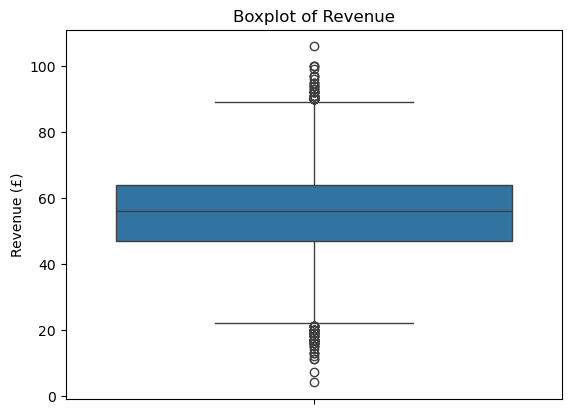

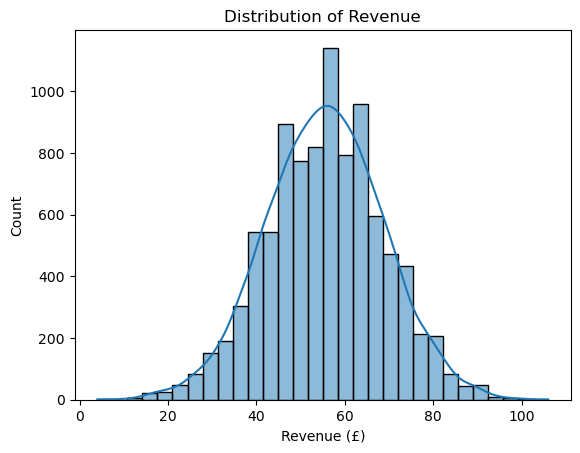

IQR bounds: (np.float64(21.5), np.float64(89.5))
Revenue outliers (count): 113
Revenue outliers (%): 1.2


,number_past_order,time_web,voucher,past_spend,ad_channel,revenue
2811,1.0,19.0,0,45.0,2,4.0
840,0.0,168.0,0,0.0,2,7.0
1122,2.0,38.0,0,24.0,2,11.0
3152,0.0,62.0,0,0.0,1,11.0
4988,1.0,48.0,0,24.0,2,12.0


,number_past_order,time_web,voucher,past_spend,ad_channel,revenue
8377,2.0,175.0,0,66.0,1,106.0
2442,1.0,168.0,0,28.0,2,100.0
927,2.0,181.0,0,66.0,1,100.0
5640,2.0,152.0,0,112.0,4,100.0
4116,1.0,161.0,0,45.0,4,99.0


In [6]:
# Boxplot and histogram of revenue
sns.boxplot(y=orders_clean["revenue"])
plt.title("Boxplot of Revenue")
plt.ylabel("Revenue (£)")
plt.show()

sns.histplot(orders_clean["revenue"], bins=30, kde=True)
plt.title("Distribution of Revenue")
plt.xlabel("Revenue (£)")
plt.show()

# IQR bounds 
Q1 = orders_clean["revenue"].quantile(0.25)
Q3 = orders_clean["revenue"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Identify outliers based on IQR 
outliers_iqr = orders_clean[(orders_clean["revenue"] < lower) | (orders_clean["revenue"] > upper)]
print("IQR bounds:", (lower, upper))
print("Revenue outliers (count):", len(outliers_iqr))
print("Revenue outliers (%):", round(len(outliers_iqr) / len(orders_clean) * 100, 2))

# Display outliers 
display(outliers_iqr.sort_values("revenue").head())
display(outliers_iqr.sort_values("revenue", ascending=False).head())

### Explatory Data Analysis

#### Grouped statistics for categorical variables


Revenue by ad_channel:


,mean,median,count
ad_channel,,,
1,55.548711,55.0,3880
2,55.469018,56.0,1985
3,55.375068,56.0,1845
4,55.416618,56.0,1709



Revenue by voucher:


,mean,median,count
voucher,,,
0,55.572864,56.0,7960
1,54.934202,55.0,1459


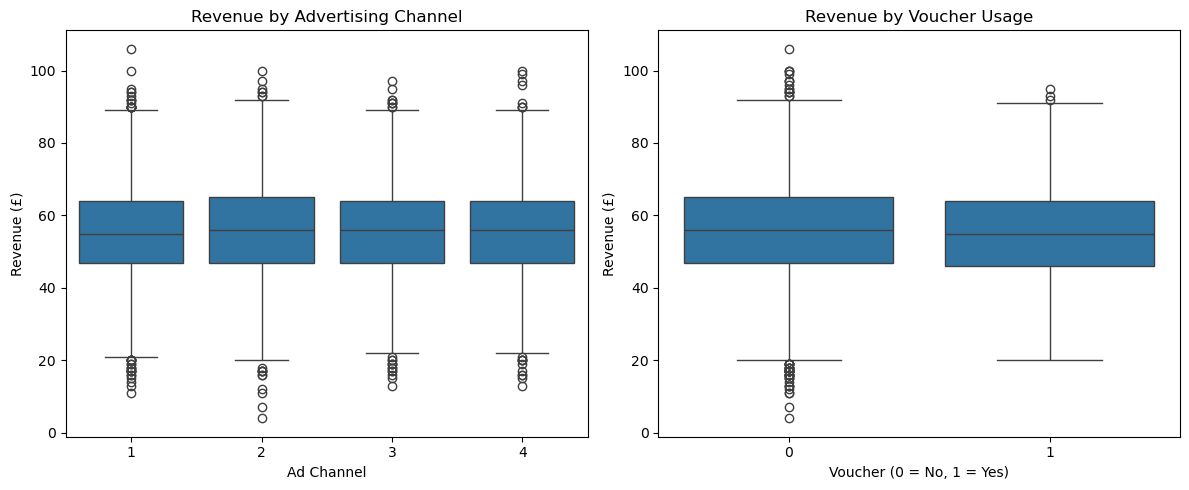

In [7]:
# grouping by categorical variables and calculating mean, median, count
print("\nRevenue by ad_channel:")
display(orders_clean.groupby("ad_channel")["revenue"].agg(["mean", "median", "count"]))

print("\nRevenue by voucher:")
display(orders_clean.groupby("voucher")["revenue"].agg(["mean", "median", "count"]))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot: Revenue by Advertising Channel
sns.boxplot(x="ad_channel", y="revenue", data=orders_clean, ax=axes[0])
axes[0].set_title("Revenue by Advertising Channel")
axes[0].set_xlabel("Ad Channel")
axes[0].set_ylabel("Revenue (£)")

# Boxplot: Revenue by Voucher Usage
sns.boxplot(x="voucher", y="revenue", data=orders_clean, ax=axes[1])
axes[1].set_title("Revenue by Voucher Usage")
axes[1].set_xlabel("Voucher (0 = No, 1 = Yes)")
axes[1].set_ylabel("Revenue (£)")

plt.tight_layout()
plt.show()


#### Exploring relationships between numerical variables and revenue

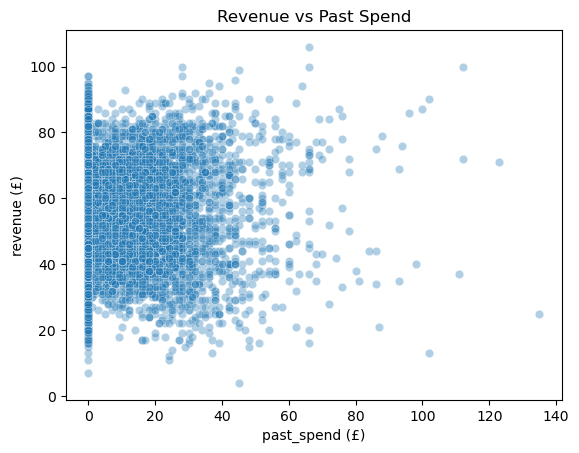

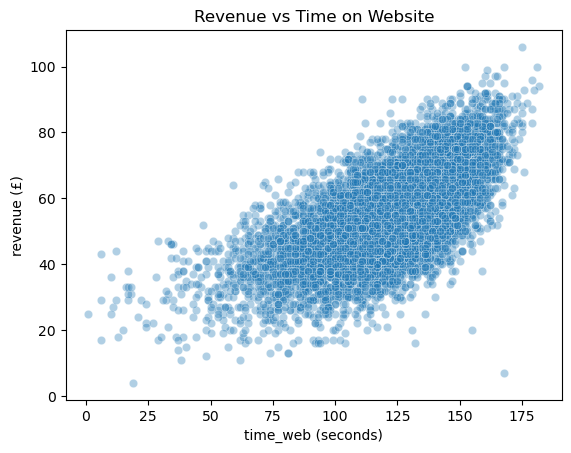

In [8]:
# Scatter plots for numerical variables
# Revenue vs past_spend
sns.scatterplot(x="past_spend", y="revenue", data=orders_clean, alpha=0.35)
plt.title("Revenue vs Past Spend")
plt.xlabel("past_spend (£)")
plt.ylabel("revenue (£)")
plt.show()


# Revenue vs time_web
sns.scatterplot(x="time_web", y="revenue", data=orders_clean, alpha=0.35)
plt.title("Revenue vs Time on Website")
plt.xlabel("time_web (seconds)")
plt.ylabel("revenue (£)")
plt.show()



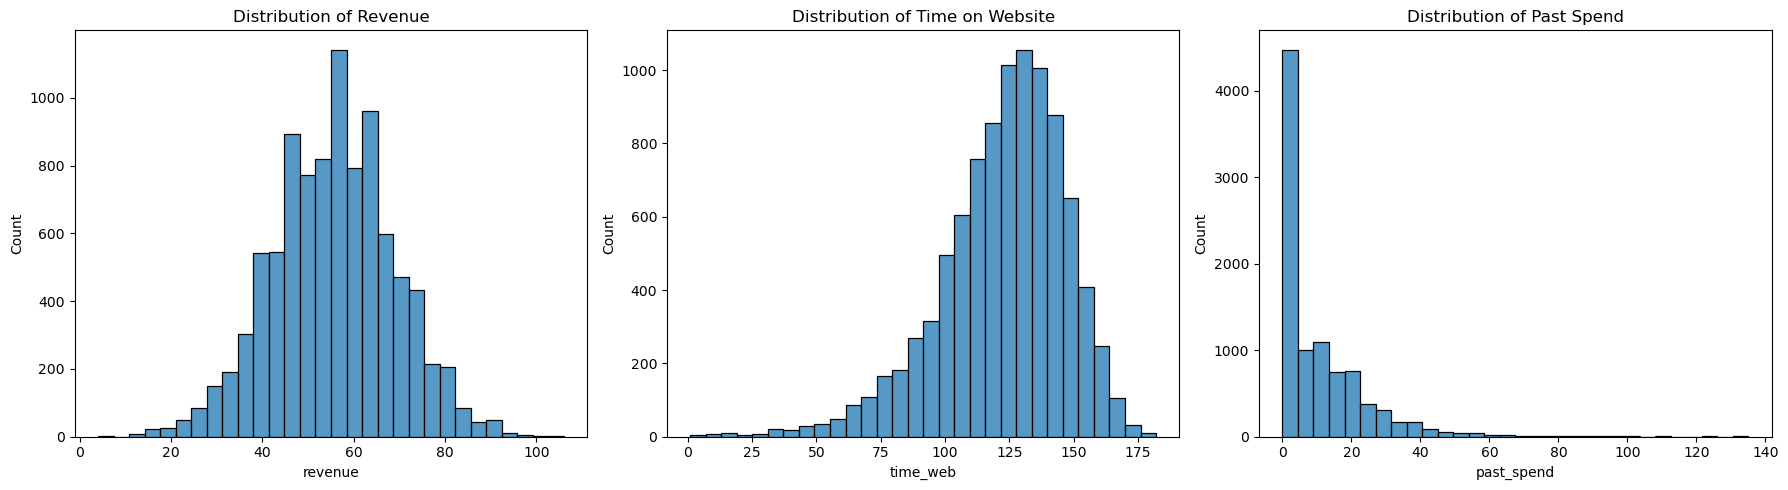

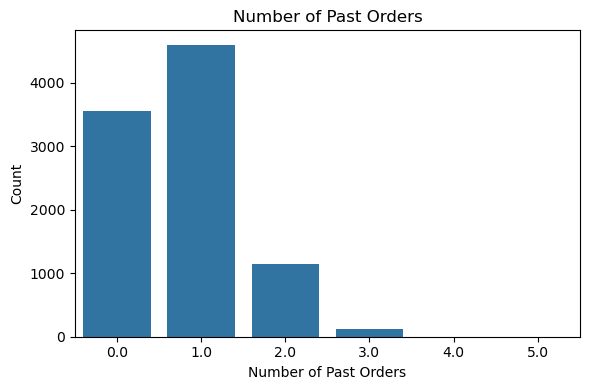

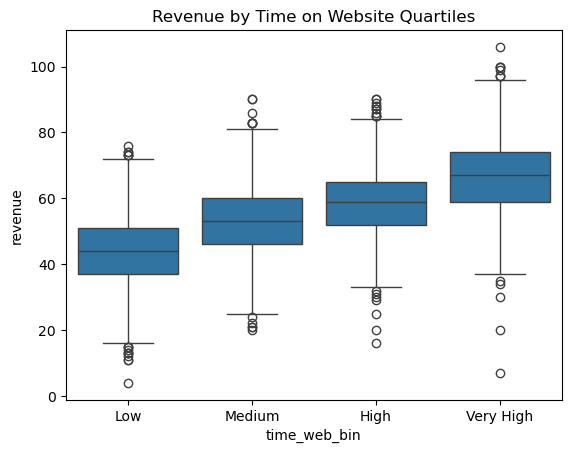

In [9]:
# Histograms for numerical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(orders_clean["revenue"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Revenue")

sns.histplot(orders_clean["time_web"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of Time on Website")

sns.histplot(orders_clean["past_spend"], bins=30, ax=axes[2])
axes[2].set_title("Distribution of Past Spend")


plt.tight_layout()
plt.show()

# Bar chart for number_past_order
plt.figure(figsize=(6, 4))
sns.countplot(x="number_past_order", data=orders_clean)
plt.title("Number of Past Orders")
plt.xlabel("Number of Past Orders")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



# Revenue vs time_web binned into quartiles
orders_clean["time_web_bin"] = pd.qcut(
    orders_clean["time_web"], 4,
    labels=["Low", "Medium", "High", "Very High"]
)

sns.boxplot(x="time_web_bin", y="revenue", data=orders_clean)
plt.title("Revenue by Time on Website Quartiles")
plt.show()

orders_clean.drop(columns=["time_web_bin"], inplace=True)

#### Correlation matrix between numerical variables

,revenue,past_spend,number_past_order,time_web,voucher
revenue,1.000000,-0.000161,-0.020886,0.665880,-0.017379
past_spend,-0.000161,1.000000,0.701292,-0.014632,-0.020638
number_past_order,-0.020886,0.701292,1.000000,-0.025442,-0.016520
time_web,0.665880,-0.014632,-0.025442,1.000000,0.004871
voucher,-0.017379,-0.020638,-0.016520,0.004871,1.000000


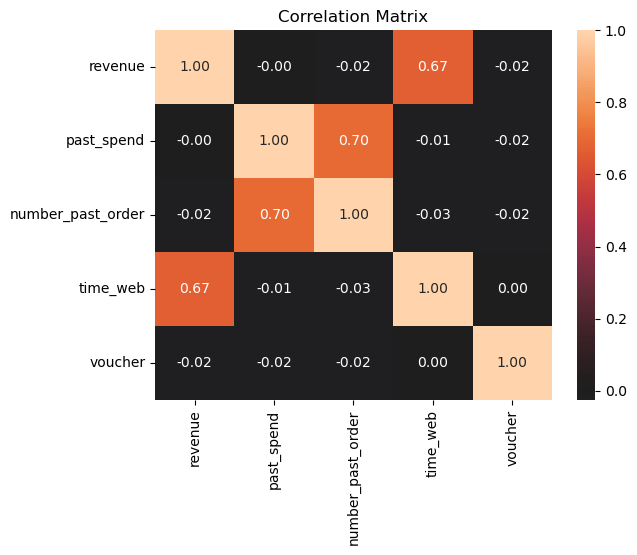

In [10]:
# Correlation (numeric only)
corr_data = orders_clean[["revenue", "past_spend", "number_past_order", "time_web", "voucher"]]
display(corr_data.corr())

sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.show()

### PREPROCESSING  SETUP (for modelling)

In [11]:
# Prepare data for modeling
orders_base = orders_clean.copy()

# Define target and features
y = orders_base["revenue"]
X = orders_base.drop(columns=["revenue"])


In [12]:
# Preprocessing pipeline
categorical_features = ["ad_channel"]
numeric_features = ["number_past_order", "past_spend", "voucher", "time_web"]

# Preprocessing and one-hot encoding of add_categorical variables
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

### MODEL (Linear Regression pipeline)

Exploratory analysis showed a clear positive relationship between time spent on the website and revenue, with an approximately linear trend and no strong evidence of non-linear patterns. Based on the visiuals, linear regression was considered an appropriate model for estimation.

In [13]:
# Final model pipeline
final_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

### Model Evaluation

Validation RMSE: 9.889
Validation MAE: 7.829
Validation R²: 0.424


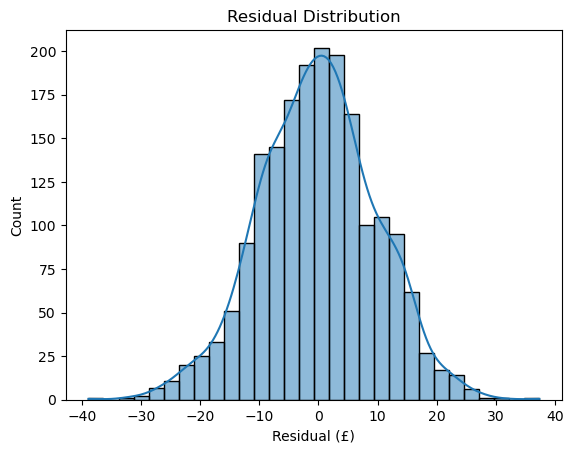

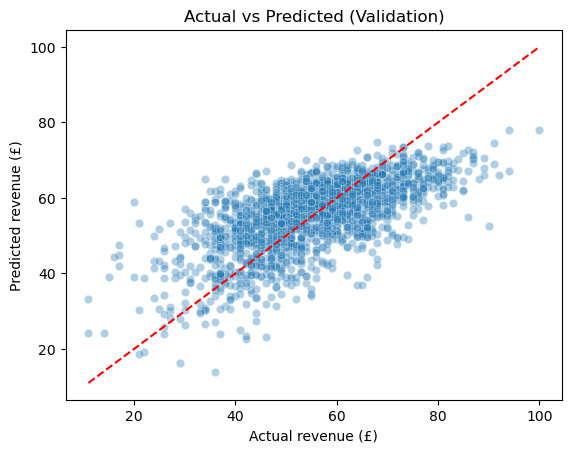

In [14]:
# Train-test split for validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fitting final model and evaluating on validation set
final_model.fit(X_train, y_train)
y_val_pred = final_model.predict(X_val)

# Evaluation metrics used
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
mae = mean_absolute_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Validation RMSE:", round(rmse, 3))
print("Validation MAE:", round(mae, 3))
print("Validation R²:", round(r2, 3))

# Residual analysis
residuals = y_val - y_val_pred

## Residual plots
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (£)")
plt.show()

# Scatter plot of actual vs predicted
sns.scatterplot(x=y_val, y=y_val_pred, alpha=0.35)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], linestyle="--", color="red")
plt.title("Actual vs Predicted (Validation)")
plt.xlabel("Actual revenue (£)")
plt.ylabel("Predicted revenue (£)")
plt.show()

In [15]:
# Coefficient (slope) and intercept
coef_time_web = final_model.named_steps["model"].coef_[-1]
intercept = final_model.named_steps["model"].intercept_

print(f"Slope (time_web): {coef_time_web:.4f}")
print(f"Intercept: {intercept:.2f}")

Slope (time_web): 0.3713
Intercept: 10.28


### Robustness Check

In this part, a robustness check was carried out by testing the model after removing duplicate observations and extreme revenue values. It turned out that this did not lead to an improvement in prediction accuracy which indicates that the model is stable and not driven by a small number of outliers abd duplicates. So, the original dataset was used for the final model and predictions.

In [16]:
# Removing duplicates and revenue outliers, then re-evaluating the model
orders_trim = orders_base.drop_duplicates().copy()

Q1 = orders_trim["revenue"].quantile(0.25)
Q3 = orders_trim["revenue"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

orders_trim = orders_trim[
    (orders_trim["revenue"] >= lower) &
    (orders_trim["revenue"] <= upper)
]

y_t = orders_trim["revenue"]
X_t = orders_trim.drop(columns=["revenue"])

X_tr, X_va, y_tr, y_va = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

final_model.fit(X_tr, y_tr)
pred_trim = final_model.predict(X_va)

rmse_trim = np.sqrt(mean_squared_error(y_va, pred_trim))
mae_trim  = mean_absolute_error(y_va, pred_trim)
r2_trim   = r2_score(y_va, pred_trim)


# Printing results for comparison
print("Baseline data:")
print(f"RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
print(f"Rows: {len(orders_base)}")

print("\nAfter dropping duplicates + revenue outliers:")
print(f"RMSE: {rmse_trim:.3f}, MAE: {mae_trim:.3f}, R²: {r2_trim:.3f}")
print(f"Rows: {len(orders_trim)}")


Baseline data:
RMSE: 9.889, MAE: 7.829, R²: 0.424
Rows: 9419

After dropping duplicates + revenue outliers:
RMSE: 9.932, MAE: 7.912, R²: 0.436
Rows: 8900


A reduced linear model using only time spent on the website achieved identical performance to the full model. This confirms that customer engagement is the primary driver of order-level revenue, with other variables providing little additional predictive value.

In [17]:
# Use only the main predictor
X = orders_clean[["time_web"]]
y = orders_clean["revenue"]

# Train–validation split (same setup as before)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit linear regression
model_time_only = LinearRegression()
model_time_only.fit(X_train, y_train)

# Predictions
y_pred = model_time_only.predict(X_val)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae  = mean_absolute_error(y_val, y_pred)
r2   = r2_score(y_val, y_pred)

print(f"Time_web only model -> RMSE: {rmse:.3f}")
print(f"Time_web only model -> MAE: {mae:.3f}")
print(f"Time_web only model -> R²: {r2:.3f}")


Time_web only model -> RMSE: 9.898
Time_web only model -> MAE: 7.838
Time_web only model -> R²: 0.423


### Predict 20 new customers

In [18]:
# Predictions for new customers
X_new = new_customers[categorical_features + numeric_features]  # excluding the order column
pred_new = final_model.predict(X_new)

prediction_table = pd.DataFrame({
    "prediction": np.round(pred_new, 2)
}, index=np.arange(1, len(pred_new) + 1))

prediction_table.index.name = "order"

display(prediction_table)

# Saving predictions to CSV file
prediction_table.to_csv("SweetAroma_predictions.csv", index=False)
print("Saved: SweetAroma_predictions.csv")


,prediction
order,
1,63.95
2,62.54
3,47.92
4,55.29
5,46.33
6,58.11
7,64.23
8,56.43
9,59.63


Saved: SweetAroma_predictions.csv
